# Imports & Configuration

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define directories and datasets
parent_dir = r"C:\\ProjectSINDyRL\\test_sindy\\test_sindy\\SINDy\\SINDy_SK"
datasets = [
    'results-sk-n2',   # South Korea, poly deg 2
    'results-ce-n2',   # CE, poly deg 2
    'results-sk-n3',   # South Korea, poly deg 3
    'results-ce-n3',   # CE, poly deg 3
    'results-sk-n2f1', # South Korea, poly deg 2 + Fourier(1)
    'results-ce-n2f1'  # CE, poly deg 2 + Fourier(1)
]
optimizers = ['SR3', 'STLSQ', 'Lasso']

# Helper Functions

In [2]:
def parse_dataset_name(name):
    """Extract dataset (SK/CE) and model (n2/n3/n2f1)."""
    if "sk" in name:
        dataset = "SK"
    elif "ce" in name:
        dataset = "CE"
    else:
        dataset = "Unknown"
    model = name.split("-")[-1]  # n2, n3, n2f1
    return dataset, model

def load_results(base_dir, opt):
    """Load RMSE and stability pickle files for a given optimizer."""
    rmse_path = os.path.join(base_dir, opt, "chunk_rmses_chunk_final.pkl")
    stability_path = os.path.join(base_dir, opt, "chunk_stability_chunk_final.pkl")
    if not os.path.exists(rmse_path) or not os.path.exists(stability_path):
        return None, None
    with open(rmse_path, "rb") as f:
        chunk_rmses = pickle.load(f)
    with open(stability_path, "rb") as f:
        chunk_stability = pickle.load(f)
    return chunk_rmses, chunk_stability

def compute_summary(dataset, opt, chunk_rmses, chunk_stability):
    dataset_label, model_label = parse_dataset_name(dataset)
    rows = []
    all_configs = set()
    for chunk in chunk_rmses.values():
        all_configs.update(chunk.keys())
    for config in sorted(all_configs):
        all_rmse_values, stable_rmse_values = [], []
        n_stable, n_total = 0, 0
        for idx in chunk_rmses:
            if config in chunk_rmses[idx]:
                rmse = chunk_rmses[idx][config]
                all_rmse_values.append(rmse)
                n_total += 1
                if config in chunk_stability.get(idx, {}) and chunk_stability[idx][config]:
                    stable_rmse_values.append(rmse)
                    n_stable += 1
        mean_all = np.mean(all_rmse_values) if all_rmse_values else np.nan
        mean_stable = np.mean(stable_rmse_values) if stable_rmse_values else np.nan
        std_stable = np.std(stable_rmse_values) if stable_rmse_values else np.nan
        frac_stable = n_stable / n_total if n_total > 0 else np.nan
        rows.append({
            "Dataset": dataset_label,
            "Model": model_label,
            "Optimizer": opt,
            "Config": config,
            "Mean_RMSE_All": mean_all,
            "Mean_RMSE_Stable": mean_stable,
            "Std_RMSE_Stable": std_stable,
            "Num_Chunks": n_total,
            "Stable_Chunks": n_stable,
            "Stability_Fraction": frac_stable
        })
    return rows


def filter_results(df, exclude_small_thr=True):
    
    if exclude_small_thr:
        mask = df["Config"].str.contains("1e-05|1e-02")
        return df.loc[~mask].copy()
    return df.copy()



# Load and Summarize Results

In [3]:
summary_rows = []
for dataset in datasets:
    base_dir = os.path.join(parent_dir, dataset)
    for opt in optimizers:
        chunk_rmses, chunk_stability = load_results(base_dir, opt)
        if chunk_rmses is None:
            print(f"Missing files for {opt} in {dataset}.")
            continue
        summary_rows.extend(compute_summary(dataset, opt, chunk_rmses, chunk_stability))

summary_df = pd.DataFrame(summary_rows)
print("===== FINAL SUMMARY TABLE =====")
print(summary_df)

===== FINAL SUMMARY TABLE =====
   Dataset Model Optimizer                 Config  Mean_RMSE_All   
0       SK    n2       SR3    L0_thr_1e-06_nu_1.0       0.042118  \
1       SK    n2       SR3    L1_thr_1e-06_nu_1.0       0.042118   
2       SK    n2       SR3    L2_thr_1e-06_nu_1.0       0.041810   
3       SK    n2     STLSQ  thr_1e-06_alpha_1e+01       0.040508   
4       SK    n2     Lasso            alpha_1e-06       0.029833   
5       CE    n2       SR3    L0_thr_1e-05_nu_1.0       0.042207   
6       CE    n2       SR3    L0_thr_1e-06_nu_1.0       0.041924   
7       CE    n2       SR3    L1_thr_1e-05_nu_1.0       0.042403   
8       CE    n2       SR3    L1_thr_1e-06_nu_1.0       0.041924   
9       CE    n2       SR3    L2_thr_1e-05_nu_1.0       0.037295   
10      CE    n2       SR3    L2_thr_1e-06_nu_1.0       0.036838   
11      CE    n2     STLSQ  thr_1e-05_alpha_1e+01       0.046618   
12      CE    n2     STLSQ  thr_1e-05_alpha_1e-02       0.045960   
13      CE    n2

In [4]:
# print out the configs in sk and ce before filtering
print("Configs in SK and CE before filtering:")
print(summary_df[["Dataset", "Model", "Optimizer", "Config"]])
summary_df = filter_results(summary_df)
print("Configs after filtering to common ones:")
#print(summary_df[["Dataset", "Model", "Optimizer", "Config"]])
#print(summary_df)



Configs in SK and CE before filtering:
   Dataset Model Optimizer                 Config
0       SK    n2       SR3    L0_thr_1e-06_nu_1.0
1       SK    n2       SR3    L1_thr_1e-06_nu_1.0
2       SK    n2       SR3    L2_thr_1e-06_nu_1.0
3       SK    n2     STLSQ  thr_1e-06_alpha_1e+01
4       SK    n2     Lasso            alpha_1e-06
5       CE    n2       SR3    L0_thr_1e-05_nu_1.0
6       CE    n2       SR3    L0_thr_1e-06_nu_1.0
7       CE    n2       SR3    L1_thr_1e-05_nu_1.0
8       CE    n2       SR3    L1_thr_1e-06_nu_1.0
9       CE    n2       SR3    L2_thr_1e-05_nu_1.0
10      CE    n2       SR3    L2_thr_1e-06_nu_1.0
11      CE    n2     STLSQ  thr_1e-05_alpha_1e+01
12      CE    n2     STLSQ  thr_1e-05_alpha_1e-02
13      CE    n2     STLSQ  thr_1e-06_alpha_1e+01
14      CE    n2     STLSQ  thr_1e-06_alpha_1e-02
15      CE    n2     Lasso            alpha_1e-05
16      CE    n2     Lasso            alpha_1e-06
17      SK    n3       SR3     L0_thr_1e-06_nu_10
18      SK 

In [5]:
# print the ce and sk results for n3, sr3, l0,l1,l2
summary_df.query("Model == 'n3' and Optimizer == 'SR3' and Config.str.contains('L0')")


,Dataset,Model,Optimizer,Config,Mean_RMSE_All,Mean_RMSE_Stable,Std_RMSE_Stable,Num_Chunks,Stable_Chunks,Stability_Fraction
17,SK,n3,SR3,L0_thr_1e-06_nu_10,0.055192,0.028418,0.040173,10402,5353,0.514613
22,CE,n3,SR3,L0_thr_1e-06_nu_1.0,0.052394,0.027609,0.042735,10939,5887,0.538166


# Comparison: SK vs CE

In [6]:
pivot_df = summary_df.pivot_table(
    index=["Model", "Optimizer", "Config"],
    columns="Dataset",
    values=["Mean_RMSE_Stable", "Std_RMSE_Stable", "Stability_Fraction"]
)
#pivot_df["RMSE_Diff_CE-SK"] = pivot_df["Mean_RMSE_Stable"]["CE"] - pivot_df["Mean_RMSE_Stable"]["SK"]
#pivot_df["Stability_Diff_CE-SK"] = pivot_df["Stability_Fraction"]["CE"] - pivot_df["Stability_Fraction"]["SK"]
print("===== CE vs SK Comparison =====")
print(pivot_df)

===== CE vs SK Comparison =====
                                      Mean_RMSE_Stable             
Dataset                                             CE        SK   
Model Optimizer Config                                             
n2    Lasso     alpha_1e-06                   0.016324  0.016074  \
      SR3       L0_thr_1e-06_nu_1.0           0.023197  0.022423   
                L1_thr_1e-06_nu_1.0           0.023197  0.022423   
                L2_thr_1e-06_nu_1.0           0.015649  0.017453   
      STLSQ     thr_1e-06_alpha_1e+01         0.025283  0.026887   
n2f1  Lasso     alpha_1e-06                   0.016041  0.016089   
      SR3       L0_thr_1e-06_nu_1.0           0.028755  0.028748   
                L1_thr_1e-06_nu_1.0           0.028755  0.028748   
                L2_thr_1e-06_nu_1.0           0.022026  0.023780   
      STLSQ     thr_1e-06_alpha_1e+01         0.029340  0.029853   
n3    Lasso     alpha_1e-06                   0.010082  0.011952   
      SR3       

In [7]:
omega_results = {}

for dataset in datasets:
    base_dir = os.path.join(parent_dir, dataset)
    for opt in optimizers:
        path = os.path.join(base_dir, opt, "omega_data_chunk_final.pkl")
        if os.path.exists(path):
            with open(path, "rb") as f:
                omega_data_chunk_final = pickle.load(f)
            # Save results with dataset + optimizer
            omega_results[(dataset, opt)] = omega_data_chunk_final
            # Print available keys in one representative chunk
            some_chunk = list(omega_data_chunk_final.keys())[0]
            #print(f"{dataset} | {opt} -> chunk {some_chunk} keys: {list(omega_data_chunk_final[some_chunk].keys())}")
        else:
            print(f"Missing: {dataset} | {opt}")


In [8]:
# Load and preprocess data
data = pd.read_pickle("C:/1. Power grid frequency data/df_South_Korea_cleansed_2024-08-15_2024-12-10.pkl")
data.index = pd.to_datetime(data.index)
data_filtered = data[(data['QI'] == 0) & (data['freq'].notna())].drop(columns=['QI']).dropna()

# Group data into 15-minute intervals
interval_groups = data_filtered.groupby(data_filtered.index.floor('15min'))  # Changed from 'H' to '15min'
valid_intervals = interval_groups.filter(lambda x: len(x) == 900)  # 15 minutes × 60 seconds = 900 samples
REF_FREQ = 60  # Hz, South Korea grid frequency
valid_intervals['omega'] = 2 * np.pi * (valid_intervals['freq'] - REF_FREQ)

# Split data into 15-minute chunks
region_data_list = [group for _, group in valid_intervals.groupby(valid_intervals.index.floor('15min'))]


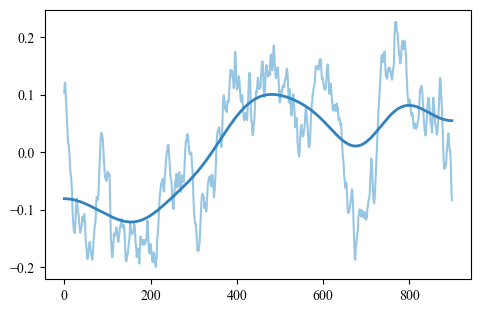

In [9]:
# select chunk index 55 for analysis
chunk_idx = 55
selected_chunk = region_data_list[chunk_idx]
selected_omega = selected_chunk['omega']

from scipy.ndimage import gaussian_filter1d
omega_filtered = gaussian_filter1d(selected_omega.values, sigma=60)  # 1 minute smoothing at 1 Hz

# for sr3, stlsq, lasso, plot the orginal, filtered data and simulated data
plt.rcParams['font.family'] = 'Times New Roman'
plt.figure(figsize=(5.5, 3.5))
plt.plot(selected_omega.values,  alpha=0.7, color='#6baed6')
plt.plot(omega_filtered, linestyle='-', linewidth=2,  color='#3182bd')
#plt.plot(simulated_omega, linestyle='--', linewidth=2, color='#08519c', label="SINDy-Lasso Simulation")

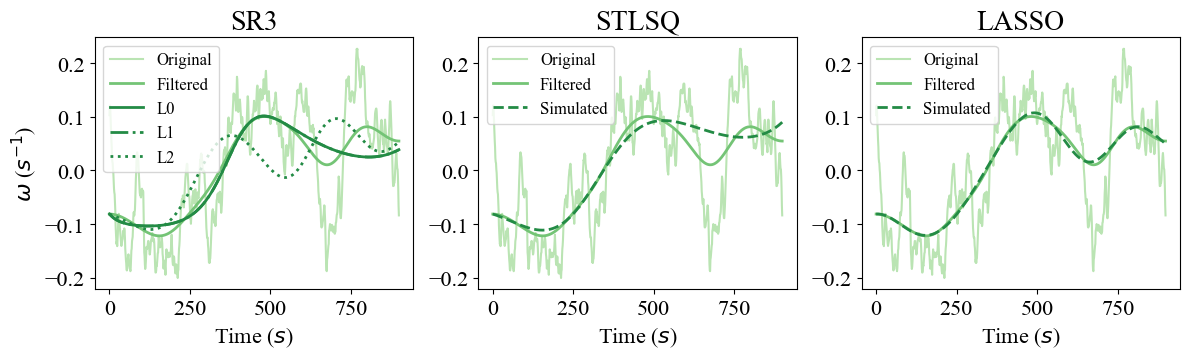

In [10]:
import matplotlib.pyplot as plt
import numpy as np

all_omega_data = omega_results
chunk_idx = 55
time = np.arange(len(region_data_list[chunk_idx]['omega'].values))
dataset_key = 'results-sk-n2'

plt.figure(figsize=(12, 3.7))

ax = plt.subplot(1, 3, 1)
original_omega = region_data_list[chunk_idx]['omega'].values
ax.plot(time, original_omega, label="Original", color="#bae4b3")
filtered_omega = all_omega_data[(dataset_key, "SR3")][chunk_idx]['L0_thr_1e-06_nu_1.0']['filtered']
ax.plot(time[:len(filtered_omega)], filtered_omega, label="Filtered", linewidth=2, color="#74c476")
styles = ["-", "-.", ":"]
for norm, style in zip(["L0", "L1", "L2"], styles):
    cfg = f"{norm}_thr_1e-06_nu_1.0"
    sim = all_omega_data[(dataset_key, "SR3")][chunk_idx][cfg]["simulated"]
    ax.plot(time[:len(sim)], sim, label=f"{norm}", linewidth=2, color="#238b45", linestyle=style)
ax.set_title(f"SR3", fontsize=20)
ax.set_xlabel('Time ($s$)', fontsize=16)
ax.set_ylabel('$\omega$ ($s^{-1}$)', fontsize=16)
ax.tick_params(axis='both', labelsize=16)
#ax.grid(True, alpha=0.3)
ax.legend(fontsize=12, loc="upper left")

ax = plt.subplot(1, 3, 2)
original_omega = region_data_list[chunk_idx]['omega'].values
filtered_omega = all_omega_data[(dataset_key, "STLSQ")][chunk_idx]['thr_1e-06_alpha_1e+01']['filtered']
simulated_omega = all_omega_data[(dataset_key, "STLSQ")][chunk_idx]['thr_1e-06_alpha_1e+01']['simulated']
ax.plot(time, original_omega, label="Original", color="#bae4b3")
ax.plot(time[:len(filtered_omega)], filtered_omega, label="Filtered", linewidth=2, color="#74c476")
ax.plot(time[:len(simulated_omega)], simulated_omega, label="Simulated", linewidth=2, color="#238b45", linestyle="--")
ax.set_title("STLSQ", fontsize=20)
ax.set_xlabel('Time ($s$)', fontsize=16)
#ax.set_ylabel("Ω (rad/s)", fontsize=16)
ax.tick_params(axis='both', labelsize=16)
#ax.grid(True, alpha=0.3)
ax.legend(fontsize=12, loc="upper left")

ax = plt.subplot(1, 3, 3)
original_omega = region_data_list[chunk_idx]['omega'].values
filtered_omega = all_omega_data[(dataset_key, "Lasso")][chunk_idx]['alpha_1e-06']['filtered']
simulated_omega = all_omega_data[(dataset_key, "Lasso")][chunk_idx]['alpha_1e-06']['simulated']
ax.plot(time, original_omega, label="Original", color="#bae4b3")
ax.plot(time[:len(filtered_omega)], filtered_omega, label="Filtered", linewidth=2, color="#74c476")
ax.plot(time[:len(simulated_omega)], simulated_omega, label="Simulated", linewidth=2, color="#238b45", linestyle="--")
ax.set_title("LASSO", fontsize=20)
ax.set_xlabel('Time ($s$)', fontsize=16)
#ax.set_ylabel("Ω (rad/s)", fontsize=16)
ax.tick_params(axis='both', labelsize=16)
#ax.grid(True, alpha=0.3)
ax.legend(fontsize=12, loc="upper left")

plt.tight_layout()
#plt.savefig('C:/4. Paper plots/IOP/optcomparison.pdf')
plt.show()


# Visualization

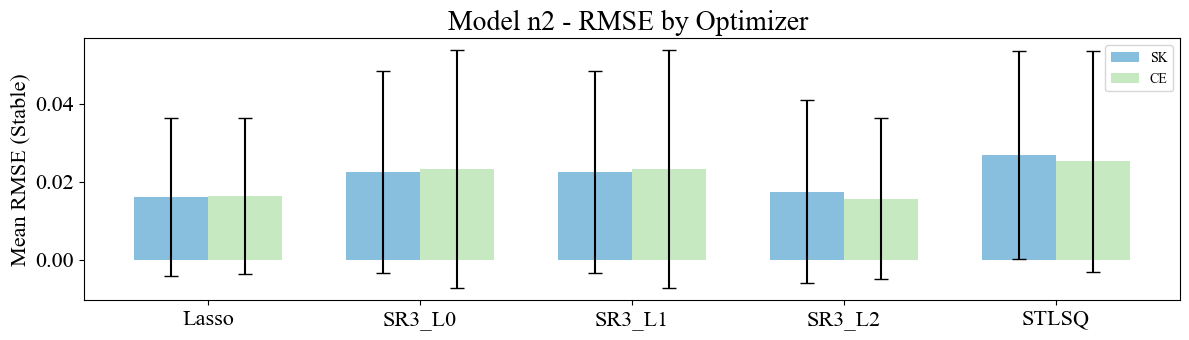


=== Model n2 - By Optimizer Summary ===
Optimizer_Reg Dataset  Mean_RMSE  Std_RMSE                Config
       SR3_L0      SK   0.022423  0.025979   L0_thr_1e-06_nu_1.0
       SR3_L1      SK   0.022423  0.025979   L1_thr_1e-06_nu_1.0
       SR3_L2      SK   0.017453  0.023576   L2_thr_1e-06_nu_1.0
        STLSQ      SK   0.026887  0.026822 thr_1e-06_alpha_1e+01
        Lasso      SK   0.016074  0.020293           alpha_1e-06
       SR3_L0      CE   0.023197  0.030619   L0_thr_1e-06_nu_1.0
       SR3_L1      CE   0.023197  0.030619   L1_thr_1e-06_nu_1.0
       SR3_L2      CE   0.015649  0.020744   L2_thr_1e-06_nu_1.0
        STLSQ      CE   0.025283  0.028417 thr_1e-06_alpha_1e+01
        Lasso      CE   0.016324  0.020136           alpha_1e-06



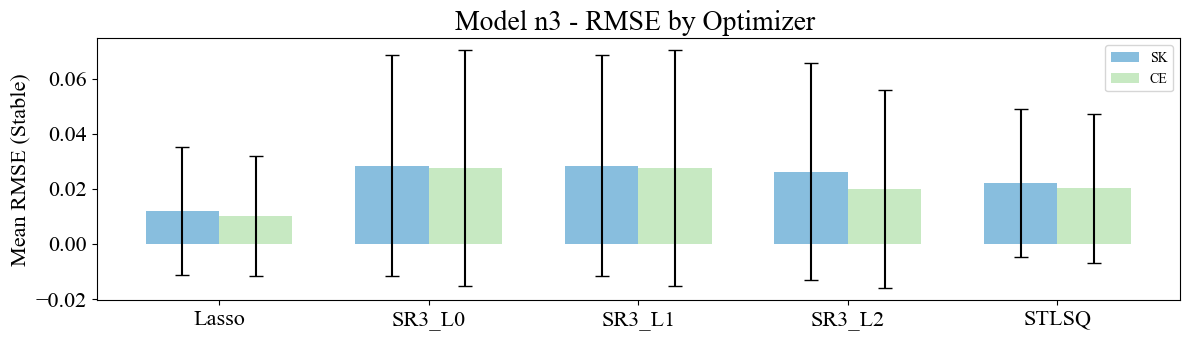


=== Model n3 - By Optimizer Summary ===
Optimizer_Reg Dataset  Mean_RMSE  Std_RMSE                Config
       SR3_L0      SK   0.028418  0.040173    L0_thr_1e-06_nu_10
       SR3_L1      SK   0.028423  0.040175    L1_thr_1e-06_nu_10
       SR3_L2      SK   0.026237  0.039358    L2_thr_1e-06_nu_10
        STLSQ      SK   0.022246  0.026837 thr_1e-06_alpha_1e+01
        Lasso      SK   0.011952  0.023338           alpha_1e-06
       SR3_L0      CE   0.027609  0.042735   L0_thr_1e-06_nu_1.0
       SR3_L1      CE   0.027601  0.042730   L1_thr_1e-06_nu_1.0
       SR3_L2      CE   0.019912  0.036026   L2_thr_1e-06_nu_1.0
        STLSQ      CE   0.020153  0.026992 thr_1e-06_alpha_1e+01
        Lasso      CE   0.010082  0.021868           alpha_1e-06



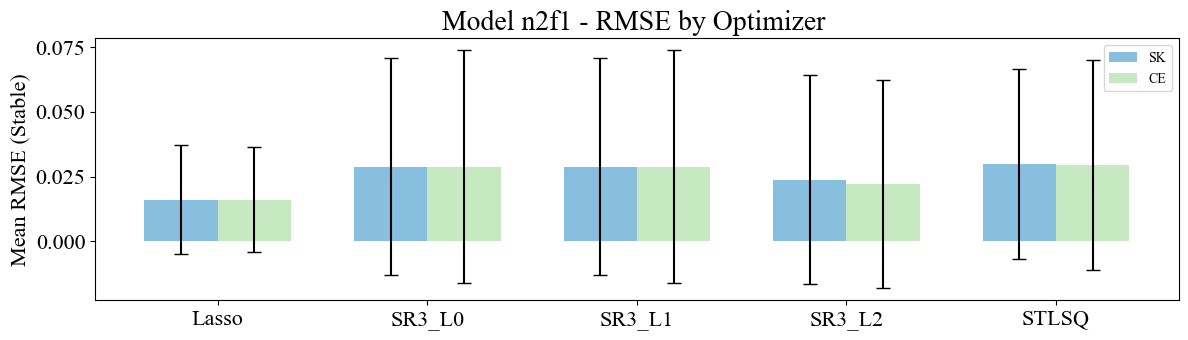


=== Model n2f1 - By Optimizer Summary ===
Optimizer_Reg Dataset  Mean_RMSE  Std_RMSE                Config
       SR3_L0      SK   0.028748  0.041976   L0_thr_1e-06_nu_1.0
       SR3_L1      SK   0.028748  0.041976   L1_thr_1e-06_nu_1.0
       SR3_L2      SK   0.023780  0.040336   L2_thr_1e-06_nu_1.0
        STLSQ      SK   0.029853  0.036726 thr_1e-06_alpha_1e+01
        Lasso      SK   0.016089  0.021237           alpha_1e-06
       SR3_L0      CE   0.028755  0.045133   L0_thr_1e-06_nu_1.0
       SR3_L1      CE   0.028755  0.045133   L1_thr_1e-06_nu_1.0
       SR3_L2      CE   0.022026  0.040301   L2_thr_1e-06_nu_1.0
        STLSQ      CE   0.029340  0.040669 thr_1e-06_alpha_1e+01
        Lasso      CE   0.016041  0.020206           alpha_1e-06



In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 设置绘图风格
plt.rcParams['font.family'] = 'Times New Roman'
#plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 20
#sns.set_style("whitegrid")

def plot_by_optimizer_with_regularization(summary_df):
    
    
    models = summary_df['Model'].unique()
    
    for model in models:
        fig, ax = plt.subplots(figsize=(12, 3.5))

        # filter current model data
        model_data = summary_df[summary_df['Model'] == model]

        # prepare data: group by optimizer and regularization type
        plot_data = []
        
        # Handle SR3 different regularization types
        sr3_configs = model_data[model_data['Optimizer'] == 'SR3']['Config'].unique()
        sr3_regularizations = []
        
        for config in sr3_configs:
            if 'L0' in config:
                sr3_regularizations.append(('SR3_L0', config))
            elif 'L1' in config:
                sr3_regularizations.append(('SR3_L1', config))
            elif 'L2' in config:
                sr3_regularizations.append(('SR3_L2', config))
            else:
                sr3_regularizations.append(('SR3_unknown', config))
        
        # Group data by dataset and optimizer+regularization
        for dataset in ['SK', 'CE']:
            dataset_data = model_data[model_data['Dataset'] == dataset]
            
            # SR3 with different regularizations
            for reg_type, config in sr3_regularizations:
                subset = dataset_data[dataset_data['Config'] == config]
                if not subset.empty:
                    plot_data.append({
                        'Optimizer_Reg': reg_type,
                        'Dataset': dataset,
                        'Mean_RMSE': subset['Mean_RMSE_Stable'].iloc[0],
                        'Std_RMSE': subset['Std_RMSE_Stable'].iloc[0],
                        'Config': config
                    })
            
            # STLSQ and Lasso 
            for opt in ['STLSQ', 'Lasso']:
                if opt in model_data['Optimizer'].values:
                    subset = dataset_data[dataset_data['Optimizer'] == opt]
                    if not subset.empty:
                        # Get the first config (assuming STLSQ and Lasso have no multiple regularization types)
                        config = subset['Config'].iloc[0]
                        plot_data.append({
                            'Optimizer_Reg': opt,
                            'Dataset': dataset,
                            'Mean_RMSE': subset['Mean_RMSE_Stable'].mean(),
                            'Std_RMSE': subset['Std_RMSE_Stable'].mean(),
                            'Config': config
                        })
        
        plot_df = pd.DataFrame(plot_data)

        # create the plot
        unique_optimizers = sorted(plot_df['Optimizer_Reg'].unique())
        x_pos = np.arange(len(unique_optimizers))
        width = 0.35

        colors = ['#6baed6', '#bae4b3']  # SK and CE colors
        
        for i, dataset in enumerate(['SK', 'CE']):
            means = []
            stds = []
            for opt_reg in unique_optimizers:
                subset = plot_df[(plot_df['Optimizer_Reg'] == opt_reg) & (plot_df['Dataset'] == dataset)]
                if not subset.empty:
                    means.append(subset['Mean_RMSE'].iloc[0])
                    stds.append(subset['Std_RMSE'].iloc[0])
                else:
                    means.append(0)
                    stds.append(0)
            
            ax.bar(x_pos + i*width, means, width, label=f'{dataset}', 
                   color=colors[i], yerr=stds, capsize=5, alpha=0.8)
        
        #ax.set_xlabel('Optimizer with Regularization')
        ax.set_ylabel('Mean RMSE (Stable)')
        ax.set_title(f'Model {model} - RMSE by Optimizer ')
        ax.set_xticks(x_pos + width/2)
        ax.set_xticklabels(unique_optimizers, fontsize=16)
        ax.legend()
        #ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # 打印统计摘要
        print(f"\n=== Model {model} - By Optimizer Summary ===")
        print(plot_df.to_string(index=False))
        print()



plot_by_optimizer_with_regularization(summary_df)



=== Model n2 - By Optimizer Summary ===
Optimizer_Reg Dataset  Mean_RMSE  Std_RMSE                Config
       SR3_L0      SK   0.022423  0.025979   L0_thr_1e-06_nu_1.0
       SR3_L1      SK   0.022423  0.025979   L1_thr_1e-06_nu_1.0
       SR3_L2      SK   0.017453  0.023576   L2_thr_1e-06_nu_1.0
        STLSQ      SK   0.026887  0.026822 thr_1e-06_alpha_1e+01
        Lasso      SK   0.016074  0.020293           alpha_1e-06
       SR3_L0      CE   0.023197  0.030619   L0_thr_1e-06_nu_1.0
       SR3_L1      CE   0.023197  0.030619   L1_thr_1e-06_nu_1.0
       SR3_L2      CE   0.015649  0.020744   L2_thr_1e-06_nu_1.0
        STLSQ      CE   0.025283  0.028417 thr_1e-06_alpha_1e+01
        Lasso      CE   0.016324  0.020136           alpha_1e-06


=== Model n3 - By Optimizer Summary ===
Optimizer_Reg Dataset  Mean_RMSE  Std_RMSE                Config
       SR3_L0      SK   0.028418  0.040173    L0_thr_1e-06_nu_10
       SR3_L1      SK   0.028423  0.040175    L1_thr_1e-06_nu_10
       

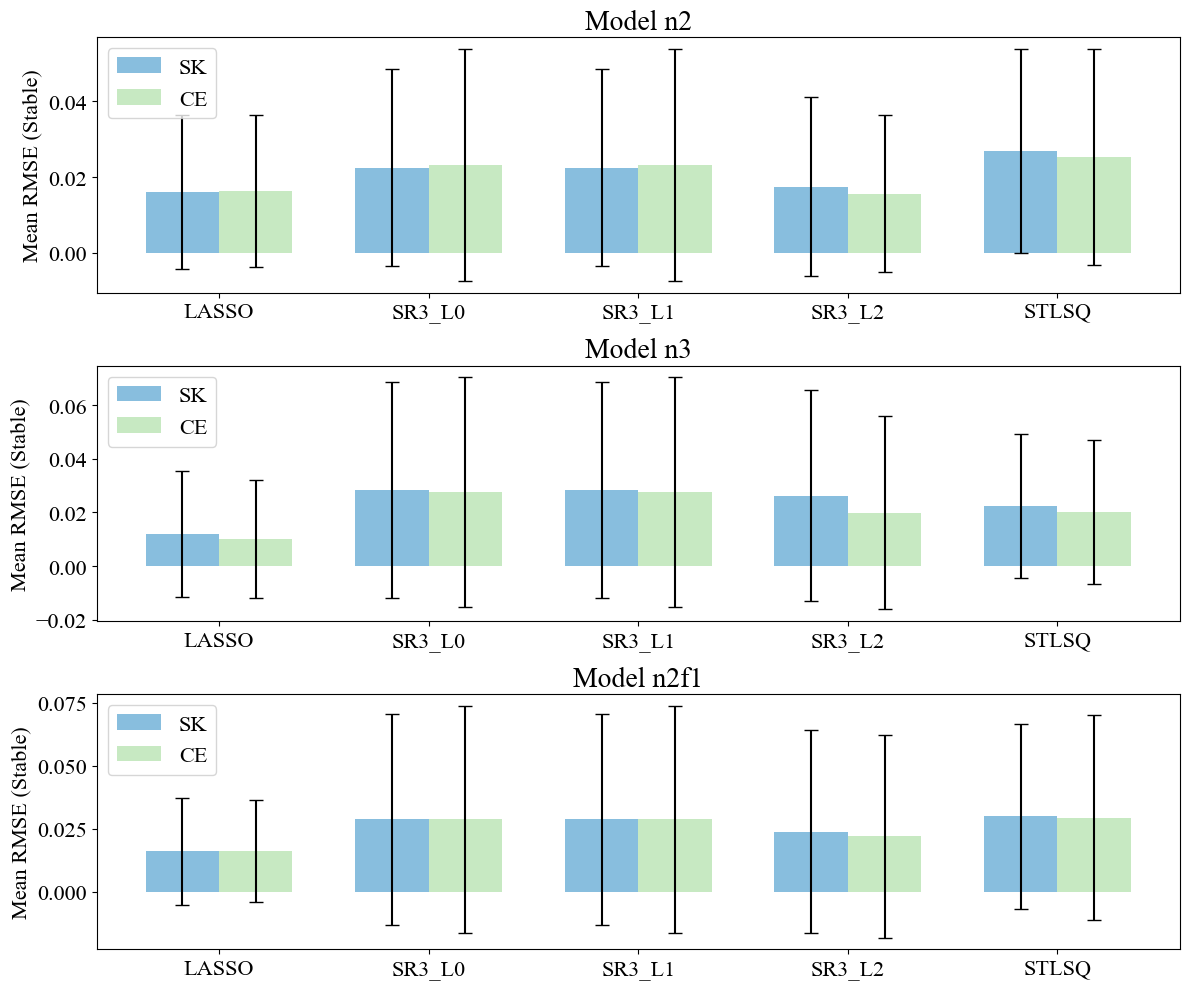

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# set plot style
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['legend.fontsize'] = 16  

def plot_by_optimizer_with_regularization_sidebyside(summary_df):
    
    models = summary_df['Model'].unique()
    
    fig, axes = plt.subplots(3, 1, figsize=(12, 10))
    
    for idx, model in enumerate(models):
        ax = axes[idx]
        
        
        model_data = summary_df[summary_df['Model'] == model]
        plot_data = []
        
        # handle SR3 different regularization types
        sr3_configs = model_data[model_data['Optimizer'] == 'SR3']['Config'].unique()
        sr3_regularizations = []
        
        for config in sr3_configs:
            if 'L0' in config:
                sr3_regularizations.append(('SR3_L0', config))
            elif 'L1' in config:
                sr3_regularizations.append(('SR3_L1', config))
            elif 'L2' in config:
                sr3_regularizations.append(('SR3_L2', config))
            else:
                sr3_regularizations.append(('SR3_unknown', config))
        
        # for each dataset and optimizer+regularization, compute stats
        for dataset in ['SK', 'CE']:
            dataset_data = model_data[model_data['Dataset'] == dataset]
            
            # SR3 different regularizations
            for reg_type, config in sr3_regularizations:
                subset = dataset_data[dataset_data['Config'] == config]
                if not subset.empty:
                    plot_data.append({
                        'Optimizer_Reg': reg_type,
                        'Dataset': dataset,
                        'Mean_RMSE': subset['Mean_RMSE_Stable'].iloc[0],
                        'Std_RMSE': subset['Std_RMSE_Stable'].iloc[0],
                        'Config': config
                    })
            
            # STLSQ, Lasso
            for opt in ['STLSQ', 'Lasso']:
                if opt in model_data['Optimizer'].values:
                    subset = dataset_data[dataset_data['Optimizer'] == opt]
                    if not subset.empty:
                        config = subset['Config'].iloc[0]
                        plot_data.append({
                            'Optimizer_Reg': opt,
                            'Dataset': dataset,
                            'Mean_RMSE': subset['Mean_RMSE_Stable'].mean(),
                            'Std_RMSE': subset['Std_RMSE_Stable'].mean(),
                            'Config': config
                        })
        
        plot_df = pd.DataFrame(plot_data)

        
        unique_optimizers = sorted(plot_df['Optimizer_Reg'].unique())
        x_pos = np.arange(len(unique_optimizers))
        width = 0.35

        colors = ['#6baed6', '#bae4b3']  # colors for SK and CE
        
        for i, dataset in enumerate(['SK', 'CE']):
            means = []
            stds = []
            for opt_reg in unique_optimizers:
                subset = plot_df[(plot_df['Optimizer_Reg'] == opt_reg) & (plot_df['Dataset'] == dataset)]
                if not subset.empty:
                    means.append(subset['Mean_RMSE'].iloc[0])
                    stds.append(subset['Std_RMSE'].iloc[0])
                else:
                    means.append(0)
                    stds.append(0)
            
            ax.bar(x_pos + i*width, means, width, label=f'{dataset}', 
                   color=colors[i], yerr=stds, capsize=5, alpha=0.8)
        
        ax.set_ylabel('Mean RMSE (Stable)')
        ax.set_title(f'Model {model}')
        ax.set_xticks(x_pos + width/2)
        
        labels = [label.replace('Lasso', 'LASSO') for label in unique_optimizers]
        ax.set_xticklabels(labels, fontsize=16)
        ax.legend(fontsize=16, loc="upper left")
        ax.grid(False)
        
        
        print(f"\n=== Model {model} - By Optimizer Summary ===")
        print(plot_df.to_string(index=False))
        print()
    
    plt.tight_layout()
    
    plt.savefig('C:/4. Paper plots/IOP/optcomparison_rmse.pdf')
    #plt.show()

# generate the side-by-side plots
plot_by_optimizer_with_regularization_sidebyside(summary_df)


=== Model p2 - By Optimizer Summary ===
Optimizer_Reg Dataset  Mean_RMSE  Std_RMSE                Config
       SR3_L0      SK   0.022423  0.025979   L0_thr_1e-06_nu_1.0
       SR3_L1      SK   0.022423  0.025979   L1_thr_1e-06_nu_1.0
       SR3_L2      SK   0.017453  0.023576   L2_thr_1e-06_nu_1.0
        STLSQ      SK   0.026887  0.026822 thr_1e-06_alpha_1e+01
        Lasso      SK   0.016074  0.020293           alpha_1e-06
       SR3_L0      CE   0.023197  0.030619   L0_thr_1e-06_nu_1.0
       SR3_L1      CE   0.023197  0.030619   L1_thr_1e-06_nu_1.0
       SR3_L2      CE   0.015649  0.020744   L2_thr_1e-06_nu_1.0
        STLSQ      CE   0.025283  0.028417 thr_1e-06_alpha_1e+01
        Lasso      CE   0.016324  0.020136           alpha_1e-06


=== Model p3 - By Optimizer Summary ===
Optimizer_Reg Dataset  Mean_RMSE  Std_RMSE                Config
       SR3_L0      SK   0.028418  0.040173    L0_thr_1e-06_nu_10
       SR3_L1      SK   0.028423  0.040175    L1_thr_1e-06_nu_10
       

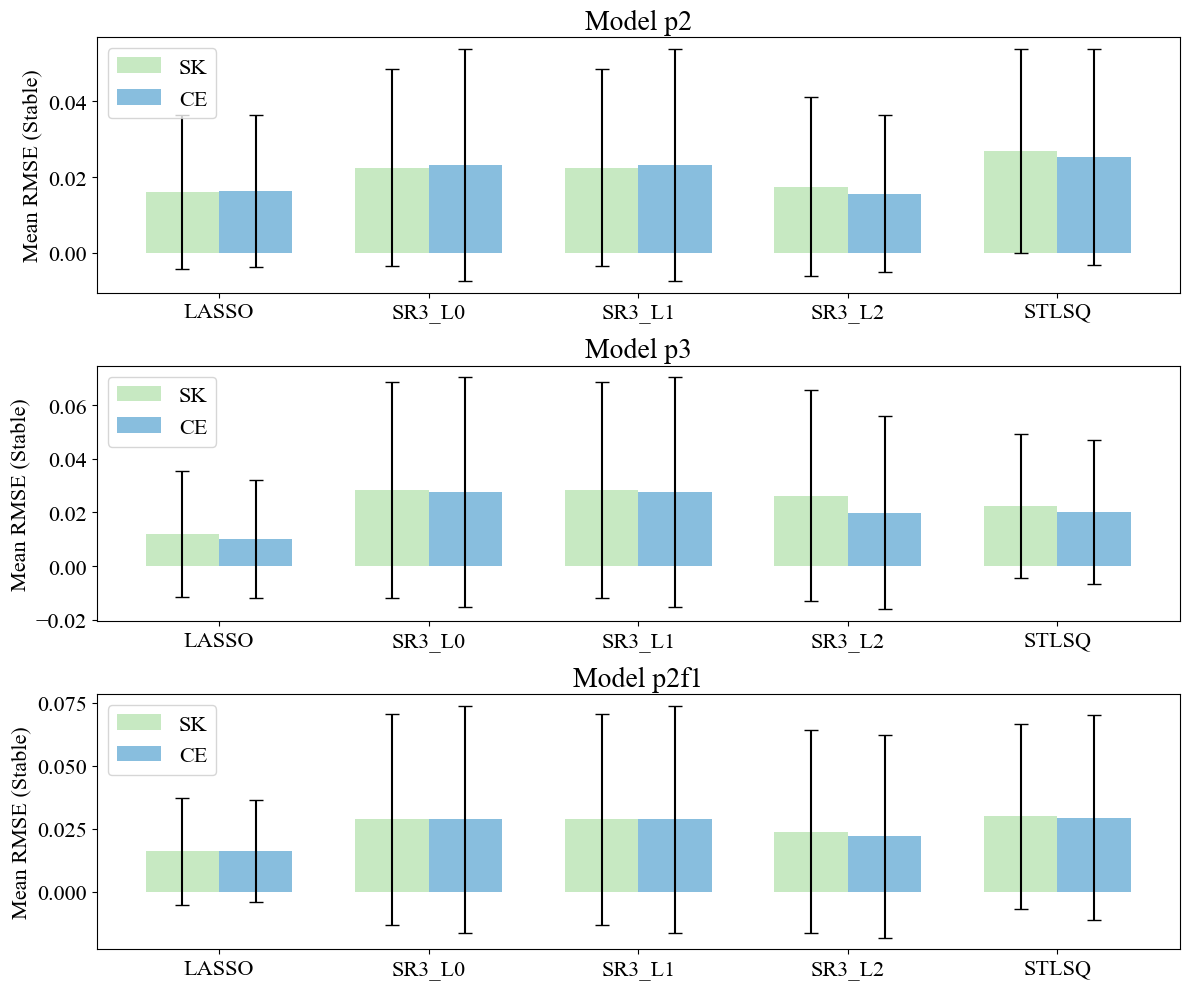

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# set plot style
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['legend.fontsize'] = 16  

def plot_by_optimizer_with_regularization_sidebyside(summary_df):
    
    # Create mapping from old model names to new model names
    model_mapping = {
        'n2': 'p2',
        'n3': 'p3', 
        'n2f1': 'p2f1'
    }
    
    # Apply the mapping to the Model column
    summary_df = summary_df.copy()
    summary_df['Model'] = summary_df['Model'].map(model_mapping)
    
    models = summary_df['Model'].unique()
    
    fig, axes = plt.subplots(3, 1, figsize=(12, 10))
    
    for idx, model in enumerate(models):
        ax = axes[idx]
        
        
        model_data = summary_df[summary_df['Model'] == model]
        plot_data = []
        
        # handle SR3 different regularization types
        sr3_configs = model_data[model_data['Optimizer'] == 'SR3']['Config'].unique()
        sr3_regularizations = []
        
        for config in sr3_configs:
            if 'L0' in config:
                sr3_regularizations.append(('SR3_L0', config))
            elif 'L1' in config:
                sr3_regularizations.append(('SR3_L1', config))
            elif 'L2' in config:
                sr3_regularizations.append(('SR3_L2', config))
            else:
                sr3_regularizations.append(('SR3_unknown', config))
        
        # for each dataset and optimizer+regularization, compute stats
        for dataset in ['SK', 'CE']:
            dataset_data = model_data[model_data['Dataset'] == dataset]
            
            # SR3 different regularizations
            for reg_type, config in sr3_regularizations:
                subset = dataset_data[dataset_data['Config'] == config]
                if not subset.empty:
                    plot_data.append({
                        'Optimizer_Reg': reg_type,
                        'Dataset': dataset,
                        'Mean_RMSE': subset['Mean_RMSE_Stable'].iloc[0],
                        'Std_RMSE': subset['Std_RMSE_Stable'].iloc[0],
                        'Config': config
                    })
            
            # STLSQ, Lasso
            for opt in ['STLSQ', 'Lasso']:
                if opt in model_data['Optimizer'].values:
                    subset = dataset_data[dataset_data['Optimizer'] == opt]
                    if not subset.empty:
                        config = subset['Config'].iloc[0]
                        plot_data.append({
                            'Optimizer_Reg': opt,
                            'Dataset': dataset,
                            'Mean_RMSE': subset['Mean_RMSE_Stable'].mean(),
                            'Std_RMSE': subset['Std_RMSE_Stable'].mean(),
                            'Config': config
                        })
        
        plot_df = pd.DataFrame(plot_data)

        
        unique_optimizers = sorted(plot_df['Optimizer_Reg'].unique())
        x_pos = np.arange(len(unique_optimizers))
        width = 0.35

        colors = ['#bae4b3', '#6baed6']  # colors for SK and CE

        for i, dataset in enumerate(['SK', 'CE']):
            means = []
            stds = []
            for opt_reg in unique_optimizers:
                subset = plot_df[(plot_df['Optimizer_Reg'] == opt_reg) & (plot_df['Dataset'] == dataset)]
                if not subset.empty:
                    means.append(subset['Mean_RMSE'].iloc[0])
                    stds.append(subset['Std_RMSE'].iloc[0])
                else:
                    means.append(0)
                    stds.append(0)
            
            ax.bar(x_pos + i*width, means, width, label=f'{dataset}', 
                   color=colors[i], yerr=stds, capsize=5, alpha=0.8)
        
        ax.set_ylabel('Mean RMSE (Stable)')
        ax.set_title(f'Model {model}')
        ax.set_xticks(x_pos + width/2)
        
        labels = [label.replace('Lasso', 'LASSO') for label in unique_optimizers]
        ax.set_xticklabels(labels, fontsize=16)
        ax.legend(fontsize=16, loc="upper left")
        ax.grid(False)
        
        
        print(f"\n=== Model {model} - By Optimizer Summary ===")
        print(plot_df.to_string(index=False))
        print()
    
    plt.tight_layout()
    
    plt.savefig('C:/4. Paper plots/IOP/optcomparison_rmse.pdf')
    #plt.show()

# generate the side-by-side plots
plot_by_optimizer_with_regularization_sidebyside(summary_df)

C:\Users\wp7528\AppData\Local\Temp\ipykernel_26848\3798492583.py:72: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, fontsize=16)


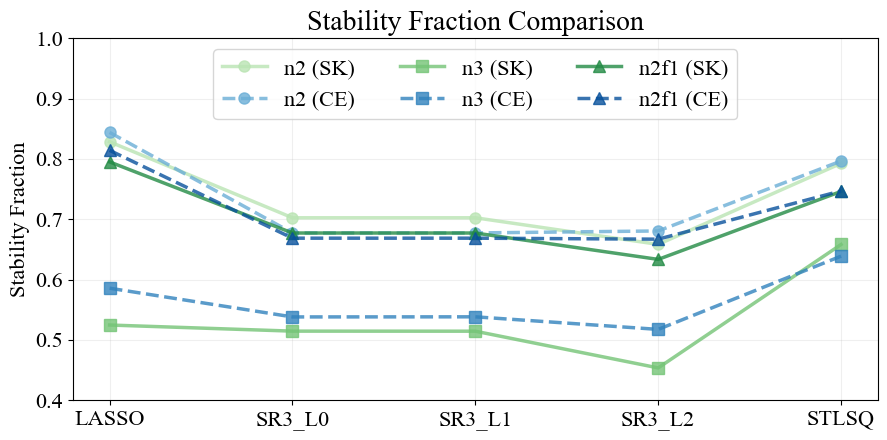

In [13]:
def plot_stability_fraction_detailed_lines(summary_df):
    
    
    # create figure
    fig, ax = plt.subplots(figsize=(9, 4.5))

    # define color scheme - each optimizer uses a different shade of the same color
    optimizer_colors_sk = ['#bae4b3', '#74c476', '#238b45']  # SK green
    optimizer_colors_ce = ['#6baed6', '#3182bd', '#08519c']  # CE blue

    # define different markers for each model
    model_markers = ['o', 's', '^']  # n2:circle, n3:square, n2f1:triangle

    # get all optimizer types (including SR3 regularization)
    all_optimizers = []
    for model in ['n2', 'n3', 'n2f1']:
        model_data = summary_df[summary_df['Model'] == model]
        sr3_configs = model_data[model_data['Optimizer'] == 'SR3']['Config'].unique()
        for config in sr3_configs:
            if 'L0' in config:
                all_optimizers.append('SR3_L0')
            elif 'L1' in config:
                all_optimizers.append('SR3_L1')
            elif 'L2' in config:
                all_optimizers.append('SR3_L2')
        all_optimizers.extend(['STLSQ', 'Lasso'])
    
    unique_optimizers = sorted(set(all_optimizers))
    x_pos = np.arange(len(unique_optimizers))

    # draw lines for each model
    for model_idx, model in enumerate(['n2', 'n3', 'n2f1']):
        model_data = summary_df[summary_df['Model'] == model]
        
        stability_sk = []
        stability_ce = []
        
        for opt_idx, opt in enumerate(unique_optimizers):
            if 'SR3' in opt:
                # 处理SR3的不同正则化
                reg_type = opt.split('_')[1]
                subset_sk = model_data[(model_data['Optimizer'] == 'SR3') & 
                                     (model_data['Dataset'] == 'SK') &
                                     (model_data['Config'].str.contains(reg_type))]
                subset_ce = model_data[(model_data['Optimizer'] == 'SR3') & 
                                     (model_data['Dataset'] == 'CE') &
                                     (model_data['Config'].str.contains(reg_type))]
            else:
                subset_sk = model_data[(model_data['Optimizer'] == opt) & 
                                     (model_data['Dataset'] == 'SK')]
                subset_ce = model_data[(model_data['Optimizer'] == opt) & 
                                     (model_data['Dataset'] == 'CE')]
            
            stability_sk.append(subset_sk['Stability_Fraction'].mean() if not subset_sk.empty else 0)
            stability_ce.append(subset_ce['Stability_Fraction'].mean() if not subset_ce.empty else 0)

        # draw lines for SK dataset - use different markers
        ax.plot(x_pos, stability_sk, 
                marker=model_markers[model_idx], linewidth=2.5, markersize=8,
                label=f'{model} (SK)', 
                color=optimizer_colors_sk[model_idx], alpha=0.8)

        # draw lines for CE dataset - use different markers, dashed style
        ax.plot(x_pos, stability_ce, 
                marker=model_markers[model_idx], linewidth=2.5, markersize=8, linestyle='--',
                label=f'{model} (CE)', 
                color=optimizer_colors_ce[model_idx], alpha=0.8)
    
    ax.set_ylabel('Stability Fraction', fontsize=16)
    ax.set_title('Stability Fraction Comparison', fontsize=20)
    labels = [label.replace('Lasso', 'LASSO') for label in unique_optimizers]
    ax.set_xticklabels(labels, fontsize=16)
    ax.set_xticks(x_pos)
    #ax.set_xticklabels(unique_optimizers,  fontsize=16)
    ax.set_ylim(0.4, 1.0)
    
    # 横向图例，放在图表上方
    ax.legend(loc='upper center', 
              ncol=3, fontsize=16, frameon=True)
    
    ax.grid(True, alpha=0.2)
    
    plt.tight_layout()
    plt.savefig('C:/4. Paper plots/IOP/stability_fraction.pdf')
    #plt.show()

# 生成详细版本
plot_stability_fraction_detailed_lines(summary_df)

In [14]:
feature_rows = []

# Define thresholds to evaluate
thresholds = [1e-6]  # use floats internally

for dataset in datasets:
    dataset_label, model_label = parse_dataset_name(dataset)
    base_dir = os.path.join(parent_dir, dataset)

    for opt in optimizers:
        coef_path = os.path.join(base_dir, opt, "coefficients_chunk_final.pkl")

        if not os.path.exists(coef_path):
            print(f"Missing coef file for {opt} in {dataset}.")
            continue

        # Load coefficients (dict: chunk_idx -> {config: coef_matrix})
        with open(coef_path, "rb") as f:
            chunk_coefs = pickle.load(f)

        # Collect all configs
        all_configs = set()
        for chunk in chunk_coefs.values():
            all_configs.update(chunk.keys())

        for config in sorted(all_configs):

            # ---- filter inconsistent configs if needed ----
            if dataset_label == "CE" and ("thr_1e-05" in config or "thr_1e-02" in config):
                continue

            # Store counts across chunks
            counts_total = {f"Num_Features_thr_{thr:g}": [] for thr in thresholds}
            counts_theta = {f"Num_Features_theta_thr_{thr:g}": [] for thr in thresholds}
            counts_omega = {f"Num_Features_omega_thr_{thr:g}": [] for thr in thresholds}

            for idx, config_dict in chunk_coefs.items():
                if config not in config_dict:
                    continue

                coef = np.array(config_dict[config])  # shape: (n_eqs, n_features)

                for thr in thresholds:
                    thr_key = f"{thr:g}"  # e.g. "1e-06"
                    mask = np.abs(coef) > thr

                    # Total features across all equations
                    counts_total[f"Num_Features_thr_{thr_key}"].append(np.sum(mask))

                    if coef.ndim == 2 and coef.shape[0] >= 2:
                        # Equation 1: theta_dot
                        counts_theta[f"Num_Features_theta_thr_{thr_key}"].append(
                            np.sum(mask[0])
                        )
                        # Equation 2: omega_dot
                        counts_omega[f"Num_Features_omega_thr_{thr_key}"].append(
                            np.sum(mask[1])
                        )

            # Summarize (mean across chunks)
            mean_total = {k: (np.mean(v) if v else np.nan) for k, v in counts_total.items()}
            mean_theta = {k: (np.mean(v) if v else np.nan) for k, v in counts_theta.items()}
            mean_omega = {k: (np.mean(v) if v else np.nan) for k, v in counts_omega.items()}

            feature_rows.append({
                "Dataset": dataset_label,
                "Model": model_label,
                "Optimizer": opt,
                "Config": config,
                **mean_total,
                **mean_theta,
                **mean_omega
            })

# Convert to DataFrame
features_df = pd.DataFrame(feature_rows)

print("\n===== FEATURE COUNT SUMMARY =====")
print(features_df.head(20))

# Merge with RMSE/stability summary
summary_with_features = summary_df.merge(
    features_df,
    on=["Dataset", "Model", "Optimizer", "Config"],
    how="left"
)

print("\n===== MERGED SUMMARY (RMSE + Features) =====")
print(summary_with_features.head(20))



===== FEATURE COUNT SUMMARY =====
   Dataset Model Optimizer                 Config  Num_Features_thr_1e-06   
0       SK    n2       SR3    L0_thr_1e-06_nu_1.0               11.473618  \
1       SK    n2       SR3    L1_thr_1e-06_nu_1.0               11.473618   
2       SK    n2       SR3    L2_thr_1e-06_nu_1.0               13.600384   
3       SK    n2     STLSQ  thr_1e-06_alpha_1e+01               11.743489   
4       SK    n2     Lasso            alpha_1e-06               10.211533   
5       CE    n2       SR3    L0_thr_1e-06_nu_1.0               11.259073   
6       CE    n2       SR3    L1_thr_1e-06_nu_1.0               11.259073   
7       CE    n2       SR3    L2_thr_1e-06_nu_1.0               13.482951   
8       CE    n2     STLSQ  thr_1e-06_alpha_1e+01               11.484596   
9       CE    n2     STLSQ  thr_1e-06_alpha_1e-02               12.040314   
10      CE    n2     Lasso            alpha_1e-05                9.779413   
11      CE    n2     Lasso            alp

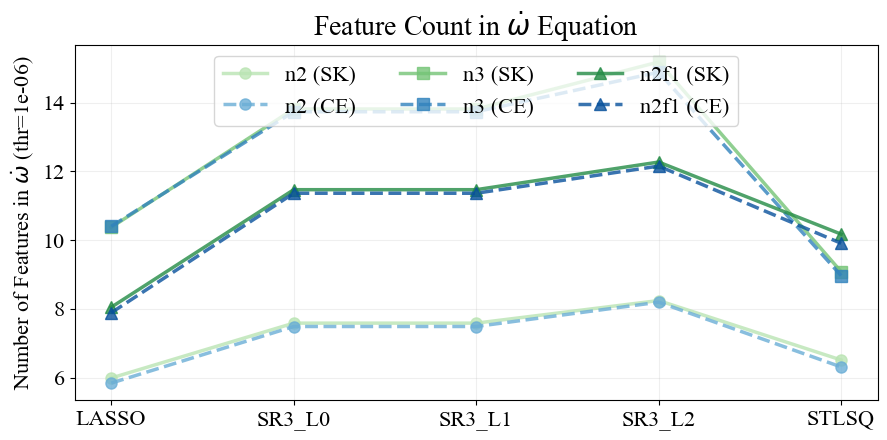

In [15]:
def plot_omega_features_detailed_lines(summary_with_features, threshold=1e-6):
    """Plot number of features in omega_dot equation in single figure with lines"""
    
    # create figure
    fig, ax = plt.subplots(figsize=(9, 4.5))

    # define color scheme - each optimizer uses a different shade of the same color
    optimizer_colors_sk = ['#bae4b3', '#74c476', '#238b45']  # SK green
    optimizer_colors_ce = ['#6baed6', '#3182bd', '#08519c']  # CE blue

    # define different markers for each model
    model_markers = ['o', 's', '^']  # n2:circle, n3:square, n2f1:triangle

    # get all optimizer types (including SR3 regularization)
    all_optimizers = []
    for model in ['n2', 'n3', 'n2f1']:
        model_data = summary_with_features[summary_with_features['Model'] == model]
        sr3_configs = model_data[model_data['Optimizer'] == 'SR3']['Config'].unique()
        for config in sr3_configs:
            if 'l0' in config.lower():
                all_optimizers.append('SR3_L0')
            elif 'l1' in config.lower():
                all_optimizers.append('SR3_L1')
            elif 'l2' in config.lower():
                all_optimizers.append('SR3_L2')
        all_optimizers.extend(['STLSQ', 'Lasso'])
    
    unique_optimizers = sorted(set(all_optimizers))
    x_pos = np.arange(len(unique_optimizers))

    # draw lines for each model
    for model_idx, model in enumerate(['n2', 'n3', 'n2f1']):
        model_data = summary_with_features[summary_with_features['Model'] == model]
        
        features_sk = []
        features_ce = []
        
        for opt_idx, opt in enumerate(unique_optimizers):
            if 'SR3' in opt:
                reg_type = opt.split('_')[1]  # 'L0', 'L1', 'L2'
                # 使用之前有效的匹配逻辑
                sk_subset = model_data[(model_data['Optimizer'] == 'SR3') & 
                                     (model_data['Dataset'] == 'SK')]
                ce_subset = model_data[(model_data['Optimizer'] == 'SR3') & 
                                     (model_data['Dataset'] == 'CE')]
                
                # 过滤特定正则化配置
                sk_configs = [cfg for cfg in sk_subset['Config'].unique() if reg_type.lower() in cfg.lower()]
                ce_configs = [cfg for cfg in ce_subset['Config'].unique() if reg_type.lower() in cfg.lower()]
                
                if sk_configs:
                    sk_filtered = sk_subset[sk_subset['Config'].isin(sk_configs)]
                    sk_value = sk_filtered[f"Num_Features_omega_thr_{threshold:g}"].mean() if not sk_filtered.empty else 0
                else:
                    sk_value = 0
                    
                if ce_configs:
                    ce_filtered = ce_subset[ce_subset['Config'].isin(ce_configs)]
                    ce_value = ce_filtered[f"Num_Features_omega_thr_{threshold:g}"].mean() if not ce_filtered.empty else 0
                else:
                    ce_value = 0
                    
            else:
                opt_name = 'Lasso' if opt == 'Lasso' else opt
                # SK data
                sk_subset = model_data[(model_data['Optimizer'] == opt_name) & 
                                     (model_data['Dataset'] == 'SK')]
                # CE data
                ce_subset = model_data[(model_data['Optimizer'] == opt_name) & 
                                     (model_data['Dataset'] == 'CE')]
                
                sk_value = sk_subset[f"Num_Features_omega_thr_{threshold:g}"].mean() if not sk_subset.empty else 0
                ce_value = ce_subset[f"Num_Features_omega_thr_{threshold:g}"].mean() if not ce_subset.empty else 0
            
            features_sk.append(sk_value if not np.isnan(sk_value) else 0)
            features_ce.append(ce_value if not np.isnan(ce_value) else 0)

        # draw lines for SK dataset - use different markers
        ax.plot(x_pos, features_sk, 
                marker=model_markers[model_idx], linewidth=2.5, markersize=8,
                label=f'{model} (SK)', 
                color=optimizer_colors_sk[model_idx], alpha=0.8)

        # draw lines for CE dataset - use different markers, dashed style
        ax.plot(x_pos, features_ce, 
                marker=model_markers[model_idx], linewidth=2.5, markersize=8, linestyle='--',
                label=f'{model} (CE)', 
                color=optimizer_colors_ce[model_idx], alpha=0.8)
    
    ax.set_ylabel(f'Number of Features in $\\dot{{\\omega}}$ (thr={threshold})', fontsize=16)
    ax.set_title('Feature Count in $\\dot{\\omega}$ Equation', fontsize=20)
    labels = [label.replace('Lasso', 'LASSO') for label in unique_optimizers]
    ax.set_xticks(x_pos)
    ax.set_xticklabels(labels, fontsize=16)
    
    # Adjust y-axis limits based on data
    feature_col = f"Num_Features_omega_thr_{threshold:g}"
    if feature_col in summary_with_features.columns:
        all_features = summary_with_features[feature_col].dropna()
        if not all_features.empty:
            y_min = max(0, all_features.min() - 0.5)
            y_max = all_features.max() + 0.5
            ax.set_ylim(y_min, y_max)
    
    
    ax.legend(loc='upper center', 
              ncol=3, fontsize=16, frameon=True)
    
    ax.grid(True, alpha=0.2)
    
    plt.tight_layout()
    #plt.savefig('C:/4. Paper plots/IOP/omega_features_detailed_lines.pdf', bbox_inches='tight')
    plt.show()


plot_omega_features_detailed_lines(summary_with_features, threshold=1e-6)

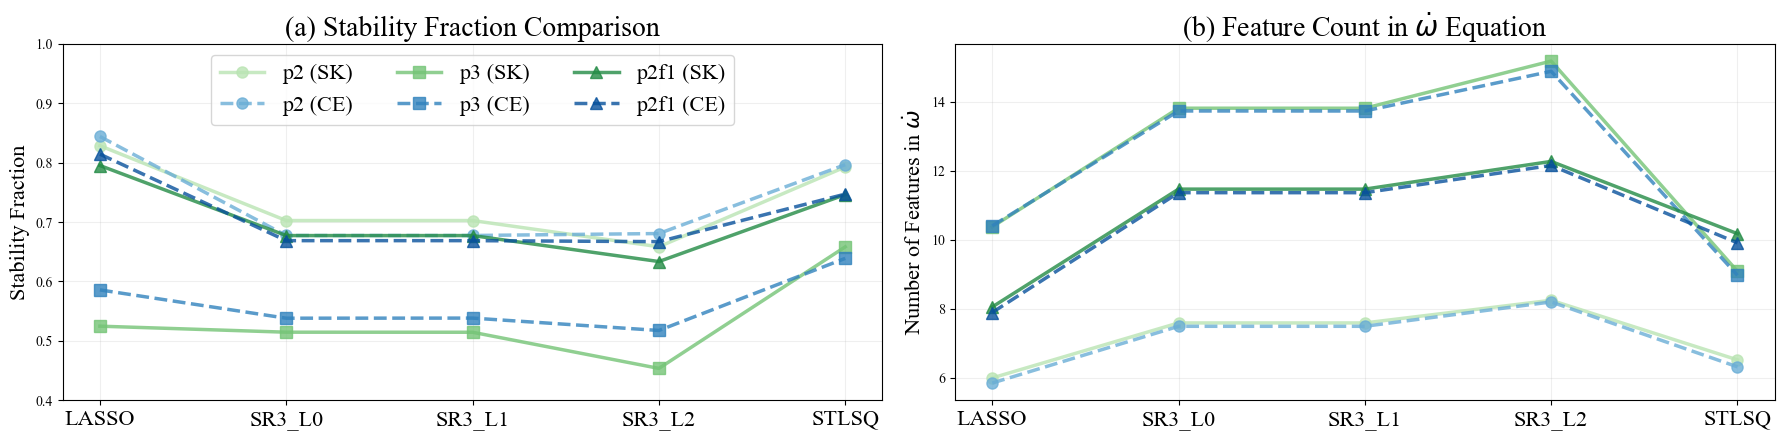

In [23]:
def plot_stability_and_features_side_by_side(summary_df, summary_with_features, threshold=1e-6):
    """Plot stability fraction and omega features in 1x2 grid"""
    
    # create 1x2 subplot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 4.5))

    # define common color scheme and markers
    optimizer_colors_sk = ['#bae4b3', '#74c476', '#238b45']  # SK green
    optimizer_colors_ce = ['#6baed6', '#3182bd', '#08519c']  # CE blue
    model_markers = ['o', 's', '^']  # p2:circle, p3:square, p2f1:triangle

    # Create model mapping
    model_mapping = {
        'n2': 'p2',
        'n3': 'p3', 
        'n2f1': 'p2f1'
    }
    
    # Apply mapping to both dataframes
    summary_df = summary_df.copy()
    summary_with_features = summary_with_features.copy()
    summary_df['Model'] = summary_df['Model'].map(model_mapping)
    summary_with_features['Model'] = summary_with_features['Model'].map(model_mapping)

    # get all optimizer types (including SR3 regularization) - use same logic for both plots
    all_optimizers = []
    for model in ['p2', 'p3', 'p2f1']:
        model_data = summary_df[summary_df['Model'] == model]
        sr3_configs = model_data[model_data['Optimizer'] == 'SR3']['Config'].unique()
        for config in sr3_configs:
            if 'L0' in config:
                all_optimizers.append('SR3_L0')
            elif 'L1' in config:
                all_optimizers.append('SR3_L1')
            elif 'L2' in config:
                all_optimizers.append('SR3_L2')
        all_optimizers.extend(['STLSQ', 'Lasso'])
    
    unique_optimizers = sorted(set(all_optimizers))
    x_pos = np.arange(len(unique_optimizers))

    # === LEFT PLOT: Stability Fraction ===
    for model_idx, model in enumerate(['p2', 'p3', 'p2f1']):
        model_data = summary_df[summary_df['Model'] == model]
        
        stability_sk = []
        stability_ce = []
        
        for opt_idx, opt in enumerate(unique_optimizers):
            if 'SR3' in opt:
                # 处理SR3的不同正则化
                reg_type = opt.split('_')[1]
                subset_sk = model_data[(model_data['Optimizer'] == 'SR3') & 
                                     (model_data['Dataset'] == 'SK') &
                                     (model_data['Config'].str.contains(reg_type))]
                subset_ce = model_data[(model_data['Optimizer'] == 'SR3') & 
                                     (model_data['Dataset'] == 'CE') &
                                     (model_data['Config'].str.contains(reg_type))]
            else:
                subset_sk = model_data[(model_data['Optimizer'] == opt) & 
                                     (model_data['Dataset'] == 'SK')]
                subset_ce = model_data[(model_data['Optimizer'] == opt) & 
                                     (model_data['Dataset'] == 'CE')]
            
            stability_sk.append(subset_sk['Stability_Fraction'].mean() if not subset_sk.empty else 0)
            stability_ce.append(subset_ce['Stability_Fraction'].mean() if not subset_ce.empty else 0)

        # draw lines for SK dataset
        ax1.plot(x_pos, stability_sk, 
                marker=model_markers[model_idx], linewidth=2.5, markersize=8,
                label=f'{model} (SK)', 
                color=optimizer_colors_sk[model_idx], alpha=0.8)

        # draw lines for CE dataset - dashed style
        ax1.plot(x_pos, stability_ce, 
                marker=model_markers[model_idx], linewidth=2.5, markersize=8, linestyle='--',
                label=f'{model} (CE)', 
                color=optimizer_colors_ce[model_idx], alpha=0.8)
    
    ax1.set_ylabel('Stability Fraction', fontsize=16)
    ax1.set_title('(a) Stability Fraction Comparison', fontsize=20)  # 添加(a)
    labels = [label.replace('Lasso', 'LASSO') for label in unique_optimizers]
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(labels, fontsize=16)
    ax1.set_ylim(0.4, 1.0)
    ax1.grid(True, alpha=0.2)

    # === RIGHT PLOT: Omega Features ===
    for model_idx, model in enumerate(['p2', 'p3', 'p2f1']):
        model_data = summary_with_features[summary_with_features['Model'] == model]
        
        features_sk = []
        features_ce = []
        
        for opt_idx, opt in enumerate(unique_optimizers):
            if 'SR3' in opt:
                reg_type = opt.split('_')[1]  # 'L0', 'L1', 'L2'
                # 使用有效的匹配逻辑
                sk_subset = model_data[(model_data['Optimizer'] == 'SR3') & 
                                     (model_data['Dataset'] == 'SK')]
                ce_subset = model_data[(model_data['Optimizer'] == 'SR3') & 
                                     (model_data['Dataset'] == 'CE')]
                
                # 过滤特定正则化配置
                sk_configs = [cfg for cfg in sk_subset['Config'].unique() if reg_type.lower() in cfg.lower()]
                ce_configs = [cfg for cfg in ce_subset['Config'].unique() if reg_type.lower() in cfg.lower()]
                
                if sk_configs:
                    sk_filtered = sk_subset[sk_subset['Config'].isin(sk_configs)]
                    sk_value = sk_filtered[f"Num_Features_omega_thr_{threshold:g}"].mean() if not sk_filtered.empty else 0
                else:
                    sk_value = 0
                    
                if ce_configs:
                    ce_filtered = ce_subset[ce_subset['Config'].isin(ce_configs)]
                    ce_value = ce_filtered[f"Num_Features_omega_thr_{threshold:g}"].mean() if not ce_filtered.empty else 0
                else:
                    ce_value = 0
                    
            else:
                opt_name = 'Lasso' if opt == 'Lasso' else opt
                # SK data
                sk_subset = model_data[(model_data['Optimizer'] == opt_name) & 
                                     (model_data['Dataset'] == 'SK')]
                # CE data
                ce_subset = model_data[(model_data['Optimizer'] == opt_name) & 
                                     (model_data['Dataset'] == 'CE')]
                
                sk_value = sk_subset[f"Num_Features_omega_thr_{threshold:g}"].mean() if not sk_subset.empty else 0
                ce_value = ce_subset[f"Num_Features_omega_thr_{threshold:g}"].mean() if not ce_subset.empty else 0
            
            features_sk.append(sk_value if not np.isnan(sk_value) else 0)
            features_ce.append(ce_value if not np.isnan(ce_value) else 0)

        # draw lines for SK dataset
        ax2.plot(x_pos, features_sk, 
                marker=model_markers[model_idx], linewidth=2.5, markersize=8,
                color=optimizer_colors_sk[model_idx], alpha=0.8)

        # draw lines for CE dataset - dashed style
        ax2.plot(x_pos, features_ce, 
                marker=model_markers[model_idx], linewidth=2.5, markersize=8, linestyle='--',
                color=optimizer_colors_ce[model_idx], alpha=0.8)
    
    ax2.set_ylabel(f'Number of Features in $\\dot{{\\omega}}$', fontsize=16)
    ax2.set_title('(b) Feature Count in $\\dot{\\omega}$ Equation', fontsize=20)  # 添加(b)
    labels = [label.replace('Lasso', 'LASSO') for label in unique_optimizers]
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(labels, fontsize=16)
    
    # Adjust y-axis limits based on data
    feature_col = f"Num_Features_omega_thr_{threshold:g}"
    if feature_col in summary_with_features.columns:
        all_features = summary_with_features[feature_col].dropna()
        if not all_features.empty:
            y_min = max(0, all_features.min() - 0.5)
            y_max = all_features.max() + 0.5
            ax2.set_ylim(y_min, y_max)
    
    ax2.grid(True, alpha=0.2)
    
    # 横向图例，放在左边图的上方中央
    ax1.legend(loc='upper center', 
              ncol=3, fontsize=16, frameon=True)
    
    plt.tight_layout()
    plt.savefig('C:/4. Paper plots/IOP/stability_and_features_1x2.pdf', bbox_inches='tight')
    plt.show()

# 生成1x2版本
plot_stability_and_features_side_by_side(summary_df, summary_with_features, threshold=1e-6)

In [16]:
def compute_feature_counts_omega(chunk_coefs, config, thresholds=[1e-6]):
    """
    Compute mean & std feature count for omega_dot across chunks.
    Return:
        {
            "Num_Features_omega_thr_1e-6_mean": float,
            "Num_Features_omega_thr_1e-6_std": float,
            ...
        }
    """
    results = {}

    # 初始化容器
    counts_omega = {f"Num_Features_omega_thr_{thr:g}": [] for thr in thresholds}

    # 遍历 chunks
    for idx, config_dict in chunk_coefs.items():
        if config not in config_dict:
            continue

        coef = np.array(config_dict[config])  # shape (n_eq, n_feat)

        # 遍历阈值
        for thr in thresholds:
            thr_key = f"{thr:g}"
            mask = np.abs(coef) > thr

            # omega_dot = row 1
            if coef.ndim == 2 and coef.shape[0] >= 2:
                counts_omega[f"Num_Features_omega_thr_{thr_key}"].append(
                    np.sum(mask[1])
                )

    # 计算 mean & std
    for thr in thresholds:
        thr_key = f"Num_Features_omega_thr_{thr:g}"
        values = counts_omega[thr_key]

        mean_val = np.mean(values) if len(values) > 0 else np.nan
        std_val = np.std(values) if len(values) > 1 else np.nan

        results[f"{thr_key}_mean"] = mean_val
        results[f"{thr_key}_std"] = std_val

    return results

print("\n===== FEATURE COUNT (OMEGA) DETAILED =====")
feature_omega_rows = [] 
thresholds = [1e-6]
for dataset in datasets:
    dataset_label, model_label = parse_dataset_name(dataset)
    base_dir = os.path.join(parent_dir, dataset)

    for opt in optimizers:
        coef_path = os.path.join(base_dir, opt, "coefficients_chunk_final.pkl")

        if not os.path.exists(coef_path):
            print(f"Missing coef file for {opt} in {dataset}.")
            continue

        # Load coefficients (dict: chunk_idx -> {config: coef_matrix})
        with open(coef_path, "rb") as f:
            chunk_coefs = pickle.load(f)

        # Collect all configs
        all_configs = set()
        for chunk in chunk_coefs.values():
            all_configs.update(chunk.keys())

        for config in sorted(all_configs):
            feature_counts = compute_feature_counts_omega(chunk_coefs, config, thresholds)

            feature_omega_rows.append({
                "Dataset": dataset_label,
                "Model": model_label,
                "Optimizer": opt,
                "Config": config,
                **feature_counts
            })
            
# Convert to DataFrame
feature_omega_df = pd.DataFrame(feature_omega_rows)
print(feature_omega_df.head(20))



===== FEATURE COUNT (OMEGA) DETAILED =====
   Dataset Model Optimizer                 Config   
0       SK    n2       SR3    L0_thr_1e-06_nu_1.0  \
1       SK    n2       SR3    L1_thr_1e-06_nu_1.0   
2       SK    n2       SR3    L2_thr_1e-06_nu_1.0   
3       SK    n2     STLSQ  thr_1e-06_alpha_1e+01   
4       SK    n2     Lasso            alpha_1e-06   
5       CE    n2       SR3    L0_thr_1e-05_nu_1.0   
6       CE    n2       SR3    L0_thr_1e-06_nu_1.0   
7       CE    n2       SR3    L1_thr_1e-05_nu_1.0   
8       CE    n2       SR3    L1_thr_1e-06_nu_1.0   
9       CE    n2       SR3    L2_thr_1e-05_nu_1.0   
10      CE    n2       SR3    L2_thr_1e-06_nu_1.0   
11      CE    n2     STLSQ  thr_1e-05_alpha_1e+01   
12      CE    n2     STLSQ  thr_1e-05_alpha_1e-02   
13      CE    n2     STLSQ  thr_1e-06_alpha_1e+01   
14      CE    n2     STLSQ  thr_1e-06_alpha_1e-02   
15      CE    n2     Lasso            alpha_1e-05   
16      CE    n2     Lasso            alpha_1e-06   
17

C:\Users\wp7528\AppData\Local\Temp\ipykernel_26848\695262755.py:144: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticks(), fontsize=16)


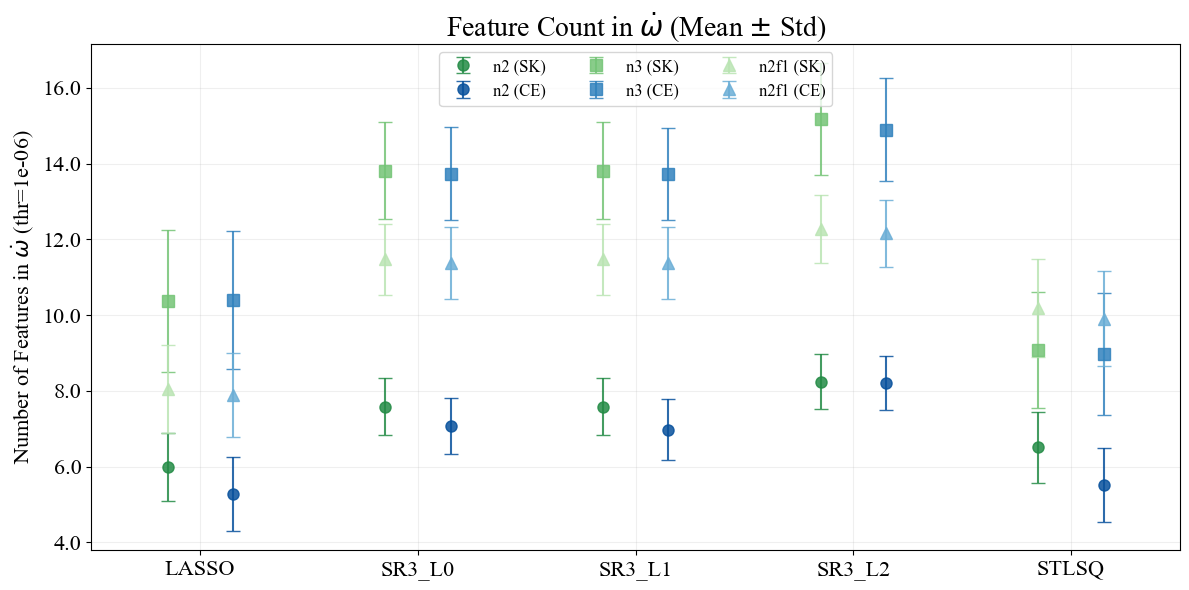

In [17]:
def plot_omega_features_points_with_errorbars(summary_with_features, threshold=1e-6):
    """
    Plot mean/std of omega_dot feature counts for each optimizer,
    with CE and SK results side-by-side (no line connecting points, no background shading).
    """

    thr_key_str = f"{threshold:g}" 

    fig, ax = plt.subplots(figsize=(12, 6)) # Increased width for side-by-side view

    optimizer_colors_sk = ['#238b45', '#74c476', '#bae4b3'] # SK greens (adjusted order)
    optimizer_colors_ce = ['#08519c', '#3182bd', '#6baed6'] # CE blues (adjusted order)
    model_markers = ['o', 's', '^']  # n2, n3, n2f1
    
    # Define a small offset for side-by-side plotting
    offset = 0.15 

    # ---- Collect optimizer names (same logic as before) ----
    all_opts = []
    for model in ['n2', 'n3', 'n2f1']:
        model_df = summary_with_features[summary_with_features['Model'] == model]

        sr3_configs = model_df[model_df['Optimizer'] == 'SR3']['Config'].unique()
        for cfg in sr3_configs:
            # Group SR3_L2, SR3_L1, SR3_L0
            if 'l2' in cfg.lower():
                all_opts.append('SR3_L2')
            elif 'l1' in cfg.lower():
                all_opts.append('SR3_L1')
            elif 'l0' in cfg.lower():
                all_opts.append('SR3_L0')

        all_opts.extend(['STLSQ', 'Lasso'])

    unique_opts_raw = sorted(set(all_opts))
    
    # --- MODIFIED: Manually define the desired order based on user request ---
    opt_order = [
        'Lasso',      # L1 regularisation (LASSO)
        'SR3_L0',     # L0 regularisation
        'SR3_L1',     # L1 regularisation
        'SR3_L2',     # L2 regularisation
        'STLSQ'       # L2 regularisation (STLSQ)
    ]
    # Filter the order to only include optimizers present in the data
    unique_opts = [opt for opt in opt_order if opt in unique_opts_raw]
    # --------------------------------------------------------------------------


    # Base x positions for each optimizer group
    base_x_pos = np.arange(len(unique_opts))
    x_tick_labels = [opt.replace("Lasso", "LASSO") for opt in unique_opts]

    y_all = []

    # ---- Loop each model ----
    for m_idx, model in enumerate(['n2', 'n3', 'n2f1']):

        model_df = summary_with_features[summary_with_features['Model'] == model]

        sk_means, sk_stds = [], []
        ce_means, ce_stds = [], []

        for opt in unique_opts:

            if 'SR3' in opt:
                reg = opt.split('_')[1].lower()
                opt_df_sk = model_df[(model_df['Optimizer'] == 'SR3') &
                                     (model_df['Dataset'] == 'SK')]
                opt_df_ce = model_df[(model_df['Optimizer'] == 'SR3') &
                                     (model_df['Dataset'] == 'CE')]

                sk_df = opt_df_sk[opt_df_sk['Config'].str.lower().str.contains(reg)]
                ce_df = opt_df_ce[opt_df_ce['Config'].str.lower().str.contains(reg)]

            else:
                real_opt = "Lasso" if opt == "Lasso" else opt
                sk_df = model_df[(model_df['Optimizer'] == real_opt) &
                                 (model_df['Dataset'] == 'SK')]
                ce_df = model_df[(model_df['Optimizer'] == real_opt) &
                                 (model_df['Dataset'] == 'CE')]

            col_mean = f"Num_Features_omega_thr_{thr_key_str}_mean"
            col_std  = f"Num_Features_omega_thr_{thr_key_str}_std"

            # Calculate mean of means and mean of stds across different configs for the same opt
            sk_mean = sk_df[col_mean].mean() if not sk_df.empty else 0
            sk_std = sk_df[col_std].mean() if not sk_df.empty else 0

            ce_mean = ce_df[col_mean].mean() if not ce_df.empty else 0
            ce_std = ce_df[col_std].mean() if not ce_df.empty else 0

            sk_means.append(sk_mean)
            sk_stds.append(sk_std)
            ce_means.append(ce_mean)
            ce_stds.append(ce_std)

            if sk_mean > 0:
                y_all += [sk_mean - sk_std, sk_mean + sk_std]
            if ce_mean > 0:
                y_all += [ce_mean - ce_std, ce_mean + ce_std]
        
        # Calculate offset x-positions for SK and CE
        sk_x_pos = base_x_pos - offset
        ce_x_pos = base_x_pos + offset

        # ---- Plot SK (Green, shifted left) ----
        ax.errorbar(
            sk_x_pos, sk_means, yerr=sk_stds,
            fmt=model_markers[m_idx],
            markersize=8,
            linestyle='none',
            markerfacecolor=optimizer_colors_sk[m_idx],
            #markeredgecolor='black',
            markeredgewidth=1,
            capsize=5,
            color=optimizer_colors_sk[m_idx],
            alpha=0.85,
            label=f"{model} (SK)"
        )

        # ---- Plot CE (Blue, shifted right) ----
        ax.errorbar(
            ce_x_pos, ce_means, yerr=ce_stds,
            fmt=model_markers[m_idx],
            markersize=8,
            linestyle='none',
            markerfacecolor=optimizer_colors_ce[m_idx],
            #markeredgecolor='black',
            markeredgewidth=1,
            capsize=5,
            color=optimizer_colors_ce[m_idx],
            alpha=0.85,
            label=f"{model} (CE)"
        )

    # ---- Axis settings ----
    ax.set_ylabel(f'Number of Features in $\\dot{{\\omega}}$ (thr={thr_key_str})', fontsize=16)
    ax.set_title('Feature Count in $\\dot{\\omega}$ (Mean $\\pm$ Std)', fontsize=20)

    # Set x-ticks at the base position (center of the SK/CE pair)
    ax.set_xticks(base_x_pos)
    ax.set_xticklabels(x_tick_labels, fontsize=16)
    ax.set_yticklabels(ax.get_yticks(), fontsize=16)
    # Set x-axis limits to provide some padding
    ax.set_xlim(base_x_pos.min() - 0.5, base_x_pos.max() + 0.5)

    if y_all:
        ax.set_ylim(max(0, min(y_all)-0.5), max(y_all)+0.5)

    ax.legend(loc='upper center', ncol=3, fontsize=12, frameon=True)
    ax.grid(True, alpha=0.2, linestyle='-')

    plt.tight_layout()
    plt.show()

plot_omega_features_points_with_errorbars(feature_omega_df, threshold=1e-6)